# Module 8 — Monetization Metrics

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

- Revenue is the number every business tracks, but on its own it can't be acted on. "Revenue went up" could mean more visitors, more of them buying, buyers ordering more often, or bigger orders, and each calls for a different response.
- This module defines the standard monetization metrics, shows that revenue equals the product of four of them, and uses that to explain each month's change on the store's data.
- It then looks at revenue over a customer's life (lifetime value, LTV) and at how concentrated revenue is among buyers.

**What this module produces:**
1. The monthly monetization table, with an exact check that revenue equals the product of its four factors.
2. Each month-to-month revenue change split into how much each factor contributed.
3. Cohort LTV curves and a revenue-concentration curve.

## From the curriculum

> ## <u>Module 8 — Monetization Metrics</u>
>
> **Upgraded from recap to full:** the A/B Testing Playbook defines ARPU and LTV
> in one paragraph
> ([`02_b2c_product_metrics.ipynb`](https://github.com/omri-sabag83/A-B-Testing-Playbook/blob/main/02_b2c_product_metrics.ipynb),
> Lesson, "Revenue/monetization metrics") but builds no worked example, so there
> was nothing with numbers to recap.
>
> **Concepts**
> - ARPU (Average Revenue Per User), ARPPU (Average Revenue Per Paying User),
>   payer conversion, AOV (Average Order Value), purchase frequency
> - The identity revenue = active users × payer rate × orders per payer × AOV,
>   and why it locates a revenue change
> - Cohort LTV (Lifetime Value): cumulative revenue per user of a starting cohort,
>   and why short windows understate it
> - Revenue concentration: what share of revenue the top payers bring
>
> **Why it matters**
> Revenue is the lagging metric every business tracks. A revenue change without
> its decomposition can't be acted on: more buyers, bigger baskets and higher
> prices call for different responses.
>
> **Worked example**
> The identity computed month by month on the running dataset, with each month's
> change split into its four factors; cohort LTV curves; a concentration curve.
>
> **Resources**
> - [16 Startup Metrics](https://a16z.com/16-startup-metrics/)
>   (Jordan, Hariharan, Chen & Kasireddy, Andreessen Horowitz, 2015, ~20 min,
>   verified): #5 on LTV and its common mistakes; #14 on why cumulative charts
>   always look good.
>
> **Exercise type:** fully worked: "revenue rose X% this month; which factor
> drove it?"
>
> **Interview angle:** "Revenue is up but ARPU is down. How is that possible?"

Notes on the quote above: this notebook calls "payer conversion" the **payer rate** and "orders per payer" **orders per buyer**. A "lagging" metric reports results after they happen (revenue), as opposed to earlier signals such as activation.

## Lesson

### The metrics

All per month, built from the event log (active users) and the semantic layer's `orders` table (buyers, orders, revenue; Module 1):
- **Active users** = users with at least one event in the month.
- **Buyers** = users with at least one order in the month.
- **Payer rate** = buyers ÷ active users (the share of active users who buy).
- **Orders per buyer** (purchase frequency) = orders ÷ buyers.
- **AOV** (Average Order Value) = revenue ÷ orders.
- **ARPU** (Average Revenue Per User) = revenue ÷ active users.
- **ARPPU** (Average Revenue Per Paying User) = revenue ÷ buyers.

### Revenue as a product of four factors

revenue = active users × (buyers ÷ active users) × (orders ÷ buyers) × (revenue ÷ orders)

= active users × payer rate × orders per buyer × AOV

This is exact, because "active users", "buyers" and "orders" cancel out. The same idea gives ARPU = payer rate × orders per buyer × AOV, and ARPPU = orders per buyer × AOV.

### Splitting a change between the four factors

When revenue changes from one month to the next, each factor changes by some ratio (this month ÷ last month), and the four ratios multiply to the revenue ratio. To say how much of the change each factor is responsible for, this module uses **log shares**:
- plain % changes don't add up to the revenue change (October → November: −8.08 + 40.03 + 0.83 + 3.37 = 36.15, while revenue rose 34.16%), because the factors multiply;
- the natural logarithm (**ln**) turns multiplying into adding (rule: ln(a × b) = ln a + ln b), so the ln of the four ratios add up exactly to the ln of the revenue ratio;
- a factor's **share** = its ln ratio ÷ the revenue's ln ratio. The four shares add up to 100%.

A **positive share** means the factor moved the same way as revenue; a **negative share**, the opposite way. A share above 100% appears only when another factor's share is negative. When revenue barely changes, its ln ratio is close to zero and shares far beyond ±100% are normal; then the factor changes themselves are the better read.

### Lifetime value (LTV)

**Cohort LTV** = revenue per user, added up from each user's first day, for a group of users who started in the same month (a **cohort**): e.g. "revenue per new user within 30 days". Short windows understate it, because customers keep buying after the window ends.

### Concentration

How much of the revenue comes from the top 1%, 10% or 20% of buyers. High concentration makes revenue sensitive to a few customers.

### Part 0 — What the data can and can't measure

- **Revenue is gross revenue** (Module 1): sum of `price` over purchase lines, refund candidates left out. No currency is recorded.
- **One purchase line = one unit** (Module 1, an assumption): if customers buy several units on a line, revenue is understated.
- **No costs:** the log has no costs or margins, so everything here is revenue, not profit.
- **Counts and revenue totals are for the 10% sample;** ratios (payer rate, AOV, ARPU, shares) need no scaling.
- **LTV windows are short:** the November cohort's last members start on 30 November, so it fits up to 92 days (30 November + 91 days = 29 February). Part 3 uses windows of 7, 30, 60 and 90 days (chosen round numbers) and shows each cohort only for the windows it fully has: all three cohorts at 7 and 30 days, only November at 90. "New users" in November may include older customers (Module 2).
- **Months differ in length:** February has 29 days, January 31. Monthly totals for February are lower for that reason alone (Module 6).

### Part 1 — The monthly monetization table

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common import connect, query, metric, show, BLUE, ORANGE, AQUA, GREY

con = connect()
month_end = {"2019-10": "2019-10-31", "2019-11": "2019-11-30", "2019-12": "2019-12-31",
             "2020-01": "2020-01-31", "2020-02": "2020-02-29"}
t = pd.DataFrame({m: {k: metric(con, k, m + "-01", e) for k in ["active_users", "buyers", "orders", "revenue"]}
                  for m, e in month_end.items()}).T
t["payer_rate"] = t["buyers"] / t["active_users"]
t["orders_per_buyer"] = t["orders"] / t["buyers"]
t["aov"] = t["revenue"] / t["orders"]
t["arpu"] = t["revenue"] / t["active_users"]
t["arppu"] = t["revenue"] / t["buyers"]
t["check"] = t["active_users"] * t["payer_rate"] * t["orders_per_buyer"] * t["aov"]
t["days"] = [31, 30, 31, 31, 29]
show(pd.DataFrame({
    "month": t.index,
    "active users": t["active_users"].map("{:,.0f}".format).values,
    "buyers": t["buyers"].map("{:,.0f}".format).values,
    "orders": t["orders"].map("{:,.0f}".format).values,
    "payer rate %": (t["payer_rate"] * 100).map("{:.2f}".format).values,
    "orders per buyer": t["orders_per_buyer"].map("{:.3f}".format).values,
    "revenue": t["revenue"].map("{:,.2f}".format).values,
    "AOV": t["aov"].map("{:.2f}".format).values,
    "check: product of 4 factors": t["check"].map("{:,.2f}".format).values,
    "ARPU": t["arpu"].map("{:.4f}".format).values,
    "ARPPU": t["arppu"].map("{:.2f}".format).values,
}))
print("\nhow much each factor moves across the five months (highest / lowest):")
for name, col, fmt in [("payer rate %", "payer_rate", "{:.2%}"), ("AOV", "aov", "{:.2f}"), ("active users", "active_users", "{:,.0f}"), ("orders per buyer", "orders_per_buyer", "{:.3f}")]:
    print(f"  {name}: {fmt.format(t[col].max())} / {fmt.format(t[col].min())} = {t[col].max() / t[col].min():.2f}")

month    active users  buyers  orders  payer rate %  orders per buyer     revenue    AOV  check: product of 4 factors    ARPU  ARPPU
2019-10        40,098   2,445   2,841          6.10             1.162  114,456.83  40.29                   114,456.83  2.8544  46.81
2019-11        36,857   3,147   3,687          8.54             1.172  153,550.09  41.65                   153,550.09  4.1661  48.79
2019-12        37,167   2,533   2,907          6.82             1.148  107,917.35  37.12                   107,917.35  2.9036  42.60
2020-01        41,105   2,809   3,268          6.83             1.163  127,663.13  39.06                   127,663.13  3.1058  45.45
2020-02        38,943   2,512   2,961          6.45             1.179  122,475.70  41.36                   122,475.70  3.1450  48.76

how much each factor moves across the five months (highest / lowest):
  payer rate %: 8.54% / 6.10% = 1.40
  AOV: 41.65 / 37.12 = 1.12
  active users: 41,105 / 36,857 = 1.12
  orders per buyer: 1.179 /

**Reading the November row, with its counts** (36,857 active users, 3,147 buyers, 3,687 orders, revenue 153,550.09):
- payer rate = 3,147 ÷ 36,857 = 8.54%
- orders per buyer = 3,687 ÷ 3,147 = 1.172
- AOV = 153,550.09 ÷ 3,687 = 41.65
- ARPU = 153,550.09 ÷ 36,857 = 4.1661; ARPPU = 153,550.09 ÷ 3,147 = 48.79

The "check" column multiplies the four factors and equals revenue in every month.

**Observation:** revenue ranges from 107,917.35 (December) to 153,550.09 (November). The payer rate moves most (highest ÷ lowest = 1.40); AOV and active users move less (1.12 each), and orders per buyer barely moves (1.03).

### Part 2 — Which factor moved revenue, month by month

For each pair of consecutive months: each factor's change in % (this month ÷ last month − 1), and its share of the revenue change (log shares, see the Lesson).

In [2]:
factors = {"active users": "active_users", "payer rate": "payer_rate", "orders per buyer": "orders_per_buyer", "AOV": "aov"}
months = list(t.index)
rows = []
for a, b in zip(months[:-1], months[1:]):
    total = np.log(t.loc[b, "revenue"] / t.loc[a, "revenue"])
    for name, col in factors.items():
        ratio = t.loc[b, col] / t.loc[a, col]
        rows.append({"change": f"{a} -> {b}", "revenue change %": (t.loc[b, 'revenue'] / t.loc[a, 'revenue'] - 1) * 100,
                     "factor": name, "factor change %": (ratio - 1) * 100, "share of revenue change %": np.log(ratio) / total * 100})
dec = pd.DataFrame(rows)
show(dec.assign(**{"revenue change %": dec["revenue change %"].map("{:+.2f}".format),
                   "factor change %": dec["factor change %"].map("{:+.2f}".format),
                   "share of revenue change %": dec["share of revenue change %"].map("{:+.1f}".format)}))
print()
print("check, October -> November: the four ln ratios add up to the revenue's ln ratio:")
a, b = "2019-10", "2019-11"
parts = [np.log(t.loc[b, c] / t.loc[a, c]) for c in factors.values()]
print("  " + " + ".join(f"{p:.4f}" for p in parts) + f" = {sum(parts):.4f};  ln({t.loc[b, 'revenue']:,.2f} / {t.loc[a, 'revenue']:,.2f}) = {np.log(t.loc[b, 'revenue'] / t.loc[a, 'revenue']):.4f}")

change              revenue change %  factor            factor change %  share of revenue change %
2019-10 -> 2019-11            +34.16  active users                -8.08                      -28.7
2019-10 -> 2019-11            +34.16  payer rate                 +40.03                     +114.6
2019-10 -> 2019-11            +34.16  orders per buyer            +0.83                       +2.8
2019-10 -> 2019-11            +34.16  AOV                         +3.37                      +11.3
2019-11 -> 2019-12            -29.72  active users                +0.84                       -2.4
2019-11 -> 2019-12            -29.72  payer rate                 -20.18                      +63.9
2019-11 -> 2019-12            -29.72  orders per buyer            -2.04                       +5.9
2019-11 -> 2019-12            -29.72  AOV                        -10.86                      +32.6
2019-12 -> 2020-01            +18.30  active users               +10.60                      +59.9
2019-12 ->

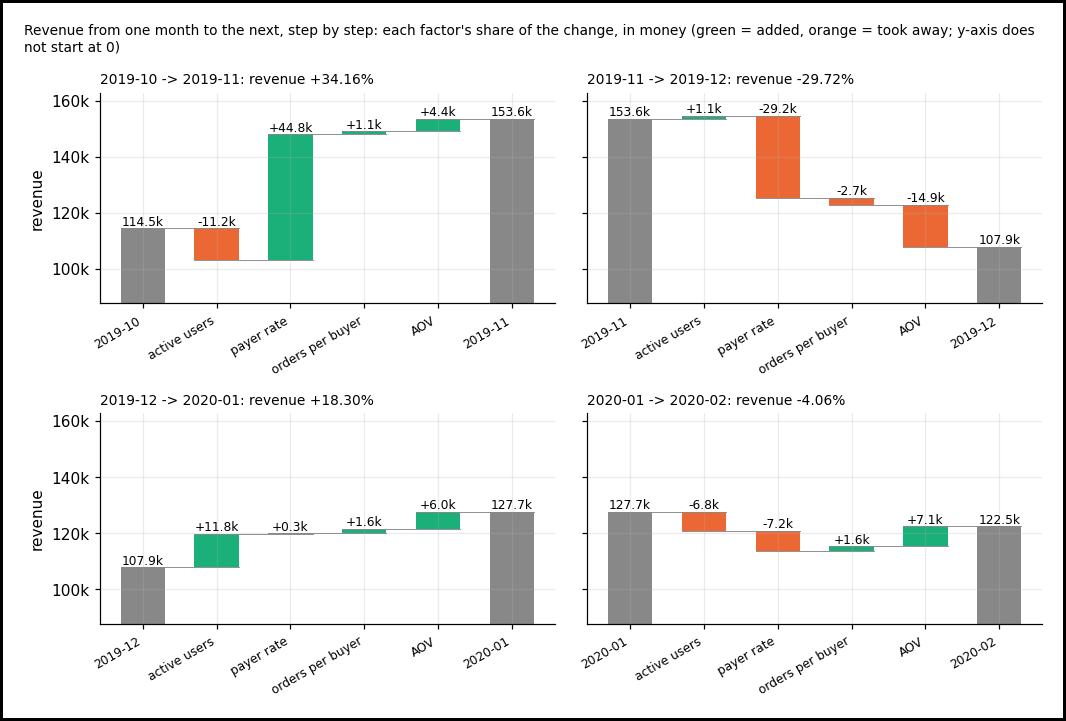

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4), sharey=True)
names = list(factors)
k = lambda v: f"{v / 1000:,.1f}k"
for ax, (chg, grp) in zip(axes.flat, dec.groupby("change", sort=False)):
    a, b = chg.split(" -> ")
    start, end = t.loc[a, "revenue"], t.loc[b, "revenue"]
    steps = grp["share of revenue change %"].values / 100 * (end - start)   # each factor's step in money
    ax.bar(0, start, color=GREY, width=0.6)
    ax.text(0, start, k(start), ha="center", va="bottom", fontsize=8)
    level = start
    for i, s in enumerate(steps, start=1):
        ax.bar(i, s, bottom=level, color=AQUA if s >= 0 else ORANGE, width=0.6)
        ax.plot([i - 1.3, i + 0.3], [level, level], color=GREY, linewidth=0.6)
        ax.text(i, max(level, level + s), f"{s / 1000:+,.1f}k", ha="center", va="bottom", fontsize=8)
        level += s
    ax.plot([len(steps) - 0.3, len(steps) + 1.3], [level, level], color=GREY, linewidth=0.6)
    ax.bar(len(steps) + 1, end, color=GREY, width=0.6)
    ax.text(len(steps) + 1, end, k(end), ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(steps) + 2), [a] + names + [b], rotation=30, ha="right", fontsize=8)
    ax.set_title(f"{chg}: revenue {grp['revenue change %'].iloc[0]:+.2f}%", fontsize=9, loc="left")
lows = [min(np.cumsum(np.r_[t.loc[a_, "revenue"], g["share of revenue change %"].values / 100 * (t.loc[b_, "revenue"] - t.loc[a_, "revenue"])]))
        for (c, g) in dec.groupby("change", sort=False) for a_, b_ in [c.split(" -> ")]]
axes[0, 0].set_ylim(min(lows) * 0.85, t["revenue"].max() * 1.06)
axes[0, 0].yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f}k")
for ax in axes[:, 0]:
    ax.set_ylabel("revenue")
fig.suptitle("Revenue from one month to the next, step by step: each factor's share of the change, in money (green = added, orange = took away; y-axis does not start at 0)",
             fontsize=9, x=0.01, ha="left", wrap=True)
plt.tight_layout(); plt.show()

**Reading October → November** (revenue +34.16%): the payer rate rose 40.03% (share +114.6%); active users fell 8.08% (share −28.7%); AOV rose 3.37% (share +11.3%) and orders per buyer 0.83% (share +2.8%). The payer rate's share is above 100% because active users pulled the other way.

**Observation:** the factor that matters changes from month to month. October → November (revenue +34.16%): the payer rate. November → December (revenue −29.72%): the payer rate first (63.9%), then AOV (32.6%). December → January (revenue +18.30%): active users first (59.9%), then AOV (30.3%).

**Observation:** January → February (revenue −4.06%): the shares run from −137.8% to +139.1%, but the factors themselves moved only about 5% each way: active users −5.26%, payer rate −5.61%, orders per buyer +1.32%, AOV +5.88%. Revenue barely changed, so the shares are not meaningful here: fewer users and a lower payer rate were mostly offset by bigger orders. (February is also two days shorter than January, Part 0.)

**What the split misses:** it says which factor moved, not why. The factors are linked: November's higher payer rate came with fewer active users, which fits a sale drawing mostly buy-ready visitors (Module 2's Hypothesis: Black Friday). A share is an accounting split, not a cause.

### Part 3 — Cohort lifetime value (LTV)

**Definitions:**
- **Cohort** = users whose first event in the data falls in the same month: November 2019, December 2019 or January 2020. October is excluded ("new" can't be measured there, Module 2); February too: a member who starts on 29 February has only 1 day of data, so not even the shortest window (7 days) fits.
- **LTV at day w** = total revenue from the cohort's orders on days 0 to w−1 after each user's own first day, divided by the cohort's size (all its users, buyers or not). Day-based, so everyone gets equal windows (Module 5).
- A window is shown only if every member of the cohort has it fully inside the data.

In [4]:
first = query(con, "SELECT user_id, MIN(event_date) AS day0 FROM events_clean GROUP BY user_id")
first["day0"] = pd.to_datetime(first["day0"])
orders = query(con, "SELECT user_id, event_date, revenue FROM orders")
orders["event_date"] = pd.to_datetime(orders["event_date"])
orders = orders.merge(first, on="user_id")
orders["day"] = (orders["event_date"] - orders["day0"]).dt.days
last_day = pd.Timestamp("2020-02-29")
ltv = {}
for c in ["2019-11", "2019-12", "2020-01"]:
    members = first[first["day0"].dt.strftime("%Y-%m") == c]
    row = {}
    for w in (7, 30, 60, 90):
        if (members["day0"] + pd.Timedelta(days=w - 1)).max() <= last_day:
            row[w] = orders[orders["user_id"].isin(members["user_id"]) & (orders["day"] < w)]["revenue"].sum() / len(members)
    ltv[(c, len(members))] = row
ltv = pd.DataFrame(ltv).T
show(pd.DataFrame({"cohort": [c for c, _ in ltv.index], "users": [f"{n:,}" for _, n in ltv.index],
                   **{f"LTV day {w}": ltv[w].map(lambda v: "" if pd.isna(v) else f"{v:.3f}").values for w in ltv.columns}}))
nov = ltv.iloc[0]
print(f"\nNovember cohort, revenue per user added in each window: days 7-30: {nov[30] - nov[7]:.3f}, days 30-60: {nov[60] - nov[30]:.3f}, days 60-90: {nov[90] - nov[60]:.3f}")

cohort    users  LTV day 7  LTV day 30  LTV day 60  LTV day 90
2019-11  31,421      2.291       3.194       3.648       4.210
2019-12  30,136      1.612       2.013       2.329
2020-01  33,029      1.521       2.130

November cohort, revenue per user added in each window: days 7-30: 0.903, days 30-60: 0.454, days 60-90: 0.562


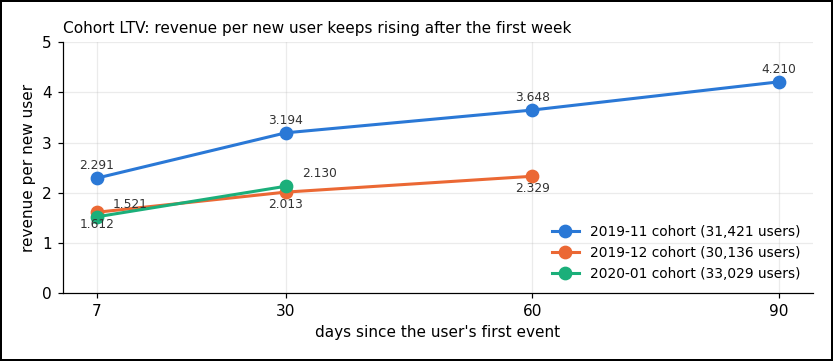

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for (c, n), color, dy, va in zip(ltv.index, [BLUE, ORANGE, AQUA], [0.12, -0.12, 0.12], ["bottom", "top", "bottom"]):
    row = ltv.loc[(c, n)].dropna()
    ax.plot(row.index, row.values, marker="o", markersize=8, linewidth=2, color=color, label=f"{c} cohort ({n:,} users)")
    for x, v in row.items():
        ax.text(x + (2 if c == "2020-01" else 0), v + dy, f"{v:.3f}", ha="left" if c == "2020-01" else "center", va=va, fontsize=8, color="#333333")
ax.set_xticks([7, 30, 60, 90])
ax.set_xlabel("days since the user's first event")
ax.set_ylabel("revenue per new user")
ax.set_ylim(0, 5)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("Cohort LTV: revenue per new user keeps rising after the first week", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** the November cohort brings 2.291 per new user within 7 days, 3.194 within 30, 3.648 within 60 and 4.210 within 90. Days 30–60 add 0.454 and days 60–90 add 0.562: the curve is not slowing down by day 90.

**Hypothesis:** two possible reasons for the bigger days 60–90 gain: customers may buy more the longer they have been around, or January and February (when November users reach days 60–90) may simply be strong months for the store. Only the November cohort reaches day 90, so the data can't tell the two apart.

**Observation:** the December and January cohorts start lower (1.612 and 1.521 per user by day 7).

**Hypothesis:** November's higher values come partly from older customers counted as "new" (Module 2: they show up as "new" mainly in November), and partly from November's high payer rate (Part 1). The event log can't separate the two.

**What LTV misses here:** 90 days is short, so these are partial values that keep growing; and it is revenue, not profit.

### Part 4 — How concentrated is the revenue?

buyers: 10,899   revenue: 626,063.10
top 1% of buyers (108): 11.93% of revenue
top 10% of buyers (1,089): 43.39% of revenue
top 20% of buyers (2,179): 59.32% of revenue
top 50% of buyers (5,449): 84.93% of revenue


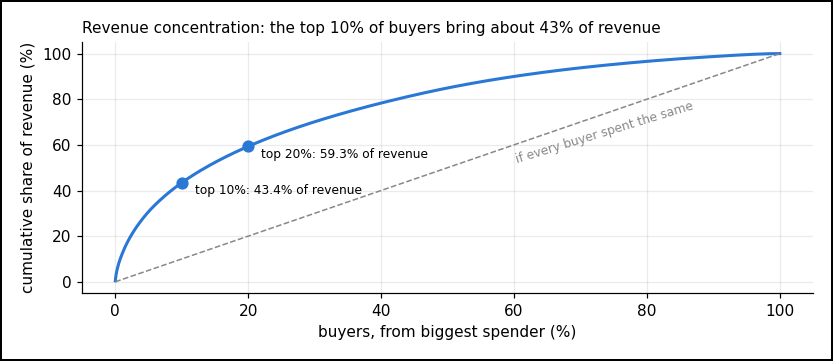

In [6]:
per_buyer = query(con, "SELECT user_id, SUM(revenue) AS revenue FROM orders GROUP BY user_id").sort_values("revenue", ascending=False)
total = per_buyer["revenue"].sum()
print(f"buyers: {len(per_buyer):,}   revenue: {total:,.2f}")
for p in (0.01, 0.10, 0.20, 0.50):
    n = max(1, int(len(per_buyer) * p))
    print(f"top {p:.0%} of buyers ({n:,}): {per_buyer['revenue'].iloc[:n].sum() / total:.2%} of revenue")
cum = per_buyer["revenue"].cumsum() / total * 100
share_of_buyers = np.arange(1, len(per_buyer) + 1) / len(per_buyer) * 100
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(share_of_buyers, cum, color=BLUE, linewidth=2)
ax.plot([0, 100], [0, 100], color=GREY, linewidth=1, linestyle="--")
ax.text(60, 52, "if every buyer spent the same", fontsize=8, color=GREY, rotation=17)
for p in (10, 20):
    v = cum.iloc[int(len(per_buyer) * p / 100) - 1]
    ax.plot(p, v, "o", color=BLUE, markersize=7)
    ax.text(p + 2, v - 5, f"top {p}%: {v:.1f}% of revenue", fontsize=8)
ax.set_xlabel("buyers, from biggest spender (%)"); ax.set_ylabel("cumulative share of revenue (%)")
ax.set_title("Revenue concentration: the top 10% of buyers bring about 43% of revenue", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** over the five months, the top 1% of buyers bring 11.93% of revenue, the top 10% bring 43.39%, and the top 20% bring 59.32%.

**What this misses:** a five-month window, so a buyer who buys once a year looks small; and concentration doesn't say whether the top buyers stay.

## Exercises

### Exercise 1 — Which factor drove the January rise?

**The question:** revenue rose from December (107,917.35) to January (127,663.13). Which factor drove it?

**Step 1, each factor's ratio, January ÷ December** (Part 1's table):

In [7]:
a, b = "2019-12", "2020-01"
print(f"revenue: {t.loc[b, 'revenue']:,.2f} / {t.loc[a, 'revenue']:,.2f} = {t.loc[b, 'revenue'] / t.loc[a, 'revenue']:.4f}")
for name, col in factors.items():
    fmt = "{:,.0f}" if col == "active_users" else "{:,.4f}"
    print(f"{name}: {fmt.format(t.loc[b, col])} / {fmt.format(t.loc[a, col])} = {t.loc[b, col] / t.loc[a, col]:.4f}")
total_ln = np.log(t.loc[b, "revenue"] / t.loc[a, "revenue"])
print(f"\nshares = ln(factor ratio) / ln(revenue ratio), with ln({t.loc[b, 'revenue'] / t.loc[a, 'revenue']:.4f}) = {total_ln:.4f}:")
for name, col in factors.items():
    l = np.log(t.loc[b, col] / t.loc[a, col])
    print(f"  {name}: ln({t.loc[b, col] / t.loc[a, col]:.4f}) / {total_ln:.4f} = {l:.4f} / {total_ln:.4f} = {l / total_ln:.1%}")

revenue: 127,663.13 / 107,917.35 = 1.1830
active users: 41,105 / 37,167 = 1.1060
payer rate: 0.0683 / 0.0682 = 1.0027
orders per buyer: 1.1634 / 1.1477 = 1.0137
AOV: 39.0646 / 37.1233 = 1.0523

shares = ln(factor ratio) / ln(revenue ratio), with ln(1.1830) = 0.1680:
  active users: ln(1.1060) / 0.1680 = 0.1007 / 0.1680 = 59.9%
  payer rate: ln(1.0027) / 0.1680 = 0.0027 / 0.1680 = 1.6%
  orders per buyer: ln(1.0137) / 0.1680 = 0.0136 / 0.1680 = 8.1%
  AOV: ln(1.0523) / 0.1680 = 0.0510 / 0.1680 = 30.3%


**Step 2, the shares:** printed above, each as ln(factor ratio) ÷ ln(revenue ratio): active users 59.9%, AOV 30.3%, orders per buyer 8.1%, payer rate 1.6%.

**Step 3, the answer:** mostly more active users (41,105 vs. 37,167), then a higher AOV. The payer rate barely moved.

### Exercise 2 — Revenue down, ARPU up

**The question:** from January to February, revenue fell, yet ARPU (revenue per active user) rose. How can both be true?

**Step 1, the two numbers that make up ARPU:**

In [8]:
a, b = "2020-01", "2020-02"
print(f"revenue:      {t.loc[a, 'revenue']:,.2f} -> {t.loc[b, 'revenue']:,.2f}  ({t.loc[b, 'revenue'] / t.loc[a, 'revenue'] - 1:+.2%})")
print(f"active users: {t.loc[a, 'active_users']:,.0f} -> {t.loc[b, 'active_users']:,.0f}  ({t.loc[b, 'active_users'] / t.loc[a, 'active_users'] - 1:+.2%})")
print(f"ARPU = revenue / active users: {t.loc[a, 'arpu']:.4f} -> {t.loc[b, 'arpu']:.4f}  ({t.loc[b, 'arpu'] / t.loc[a, 'arpu'] - 1:+.2%})")
ra, rb = t.loc[a, 'revenue'] / t.loc[a, 'days'], t.loc[b, 'revenue'] / t.loc[b, 'days']
print(f"revenue per day: {t.loc[a, 'revenue']:,.2f} / {t.loc[a, 'days']} = {ra:,.2f} -> {t.loc[b, 'revenue']:,.2f} / {t.loc[b, 'days']} = {rb:,.2f}  ({rb / ra - 1:+.2%})")

revenue:      127,663.13 -> 122,475.70  (-4.06%)
active users: 41,105 -> 38,943  (-5.26%)
ARPU = revenue / active users: 3.1058 -> 3.1450  (+1.26%)
revenue per day: 127,663.13 / 31 = 4,118.17 -> 122,475.70 / 29 = 4,223.30  (+2.55%)


**Step 2, the answer:** ARPU = revenue ÷ active users. Revenue fell by 4.06%, but active users fell by more (5.26%), so revenue per active user rose (by 1.26%). The mirror case, "revenue up, ARPU down", happens when active users grow faster than revenue.

**Step 3, a check worth making:** February has 29 days, January 31. Per day, revenue rose by 2.55%: February's monthly fall is the shorter month, not lower daily sales.

## Key takeaways

- **Observation:** revenue = active users × payer rate × orders per buyer × AOV, exactly; on this store the payer rate moves most (highest ÷ lowest = 1.40), orders per buyer least (1.03).
- **Observation:** the factor behind a revenue change differs by month (payer rate in October → November; active users in December → January). When revenue barely changes (January → February: −4.06%), shares are not meaningful; read the factor changes instead.
- **Observation:** the November cohort brings 4.210 per new user on average within 90 days, and the curve is not slowing down.
- **Observation:** the top 10% of buyers bring 43.39% of revenue.
- **Conclusion:** report revenue together with its four factors; the split shows *which* factor moved, not *why*.